# CakapKarier AI - Career Match Experiment

Notebook ini menjadi ringkasan kerja AI Engineer untuk capstone: assessment dataset scraping Glints, preprocessing, training TensorFlow Functional API, custom component, evaluasi, export model, inference, API contract, dan TensorBoard.

Logic utama tetap disimpan di module Python agar reproducible dan mudah dipakai oleh backend. Notebook ini berperan sebagai laporan eksperimen dan demo.

## 1. Setup Path dan Konfigurasi

Cell ini dibuat robust agar notebook bisa dijalankan dari folder repo root, folder `AIEngine`, atau langsung dari folder `notebooks`.

In [1]:
from pathlib import Path
import importlib
import json
import sys

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


def find_ai_engine_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if path.name == 'AIEngine' and (path / 'pipelines').exists():
            return path
        candidate = path / 'AIEngine'
        if (candidate / 'pipelines').exists():
            return candidate
    raise RuntimeError('Folder AIEngine tidak ditemukan dari current working directory.')


AIENGINE_ROOT = find_ai_engine_root(Path.cwd())
REPO_ROOT = AIENGINE_ROOT.parent
SERVICE_SRC = AIENGINE_ROOT / 'services' / 'career-match' / 'src'

for path in [AIENGINE_ROOT, SERVICE_SRC]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

RAW_PATH = AIENGINE_ROOT / 'data' / 'raw' / 'glints_jobs.csv'
PROCESSED_DIR = AIENGINE_ROOT / 'data' / 'processed' / 'career-match-v1'
MODEL_DIR = AIENGINE_ROOT / 'models' / 'registry' / 'career-match' / 'v1'

# Ubah menjadi True jika ingin menjalankan ulang dari awal.
RUN_PREPROCESSING = False
RUN_TRAINING = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

def plot_barh(series, title, xlabel='Count', color='#2563eb'):
    ax = series.sort_values().plot(kind='barh', color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

print('AIENGINE_ROOT =', AIENGINE_ROOT)
print('RAW_PATH exists =', RAW_PATH.exists())
print('MODEL_DIR exists =', MODEL_DIR.exists())

AIENGINE_ROOT = C:\DBS Foundation\CakapKarier AI\AIEngine
RAW_PATH exists = True
MODEL_DIR exists = True


## 2. Business Objective

Project CakapKarier AI membutuhkan model untuk membantu pengguna memahami kesiapan kerja, role yang paling relevan, skill gap, dan rekomendasi pengembangan skill. Karena dataset yang tersedia berisi lowongan kerja, model dibangun sebagai career matching model: kandidat dibandingkan terhadap katalog lowongan, lalu sistem mengembalikan readiness score dan rekomendasi role terbaik.

Checklist yang dipenuhi:

- TensorFlow Functional API
- Custom Layer: `CosineSimilarityLayer`, `AbsoluteDifferenceLayer`
- Custom Loss Function: `CareerMatchLoss`
- Custom Callback: `QualityThresholdCallback`
- Custom training loop dengan `tf.GradientTape`
- Export `.keras` dan SavedModel
- Inference code dan FastAPI service
- TensorBoard log
- Optional GenAI summary fallback

## 3. Raw Dataset Assessment

In [2]:
raw_df = pd.read_csv(RAW_PATH)

raw_summary = {
    'rows': len(raw_df),
    'columns': list(raw_df.columns),
    'missing_values': raw_df.isna().sum().to_dict(),
    'duplicate_job_detail': int(raw_df.duplicated('job_detail').sum()) if 'job_detail' in raw_df else None,
    'unique_job_titles': int(raw_df['job_title'].nunique()) if 'job_title' in raw_df else None,
}
raw_summary

{'rows': 990,
 'columns': ['web_scraper_order',
  'web_scraper_start_url',
  'job_title',
  'company',
  'location',
  'job_detail',
  'description',
  'requirements',
  'Skills',
  'job_benefits'],
 'missing_values': {'web_scraper_order': 0,
  'web_scraper_start_url': 0,
  'job_title': 0,
  'company': 0,
  'location': 0,
  'job_detail': 0,
  'description': 0,
  'requirements': 0,
  'Skills': 0,
  'job_benefits': 222},
 'duplicate_job_detail': 0,
 'unique_job_titles': 738}

,job_title,company,location,requirements,Skills
0,Technical Support Intern,WIRAKOM SISTEM,"Tangerang Selatan, Banten",Job RequirementsOn-site1 - 3 years of experien...,SkillsTechnical SupportIT SupportNetwork Troub...
1,Mandarin Secretary,PT. Sentum Teknologi Indonesia,"Jakarta Utara, DKI Jakarta",Job RequirementsOn-site1 - 3 years of experien...,SkillsCommunication SkillsMicrosoft OfficeAdmi...
2,Sales Manager,PT United Teknologi Integrasi,"Jakarta Pusat, DKI Jakarta",Job RequirementsOn-site3 - 5 years of experien...,SkillsGive it a try! - 1 of 12 skills match yo...
3,Project Manager,Bisnis Adviz Solusi,"Jakarta Pusat, DKI Jakarta",Job RequirementsOn-site3 - 5 years of experien...,SkillsProject ManagementRisk ManagementTeam Ma...
4,"Software Developer (Java Springboot, Golang, R...",PT Sigma Global Teknologi,"Jakarta Selatan, DKI Jakarta",Job RequirementsOn-site5 - 10 years of experie...,SkillsSpringbootCore JavaSoftware DevelopmentJ...


,count
job_title,
IT Support,16
IT Project Manager,14
IT Business Analyst,14
System Analyst,12
Data Engineer,11
IT Support Engineer,10
Software Developer,9
ETL Developer,9
Staff IT,9


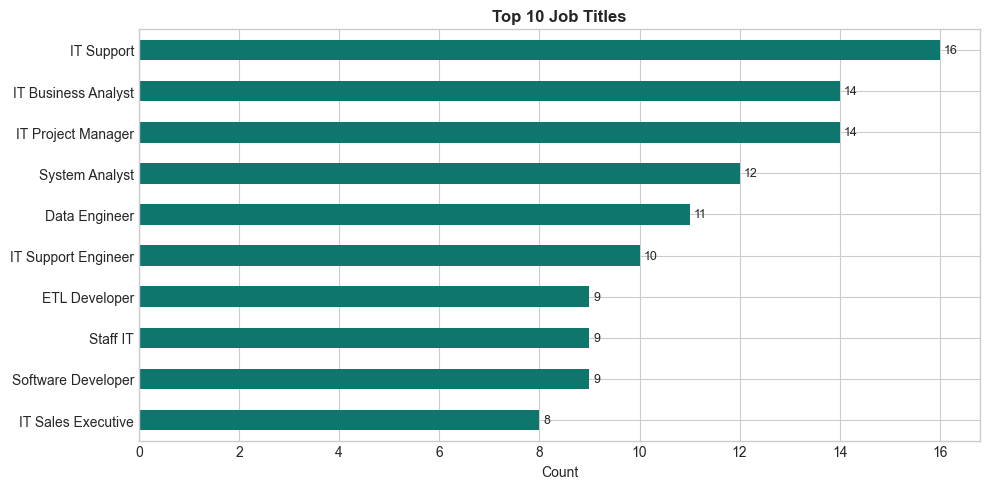

,count
location,
"Jakarta Selatan, DKI Jakarta",281
"Jakarta Pusat, DKI Jakarta",88
"Jakarta Barat, DKI Jakarta",70
"Surabaya, Jawa Timur",61
"Jakarta Utara, DKI Jakarta",51
"Tangerang, Banten",40
"Jakarta Timur, DKI Jakarta",38
"Tangerang Selatan, Banten",34
"Kab. Sleman, DI Yogyakarta",29


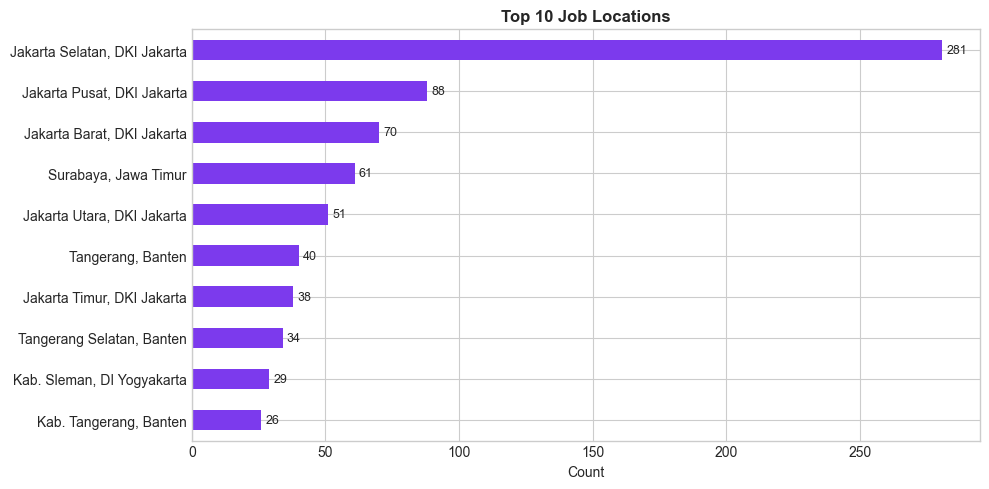

,missing_count
job_benefits,222


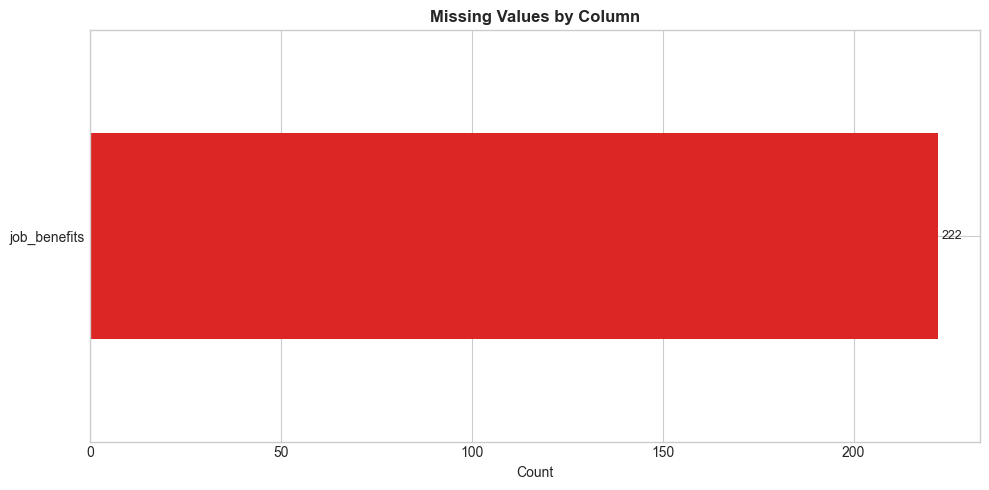

In [3]:
display(raw_df[['job_title', 'company', 'location', 'requirements', 'Skills']].head(5))

top_titles = raw_df['job_title'].value_counts().head(10)
top_locations = raw_df['location'].value_counts().head(10)
missing_values = raw_df.isna().sum().sort_values(ascending=False)

display(top_titles.rename('count').to_frame())
plot_barh(top_titles, 'Top 10 Job Titles', color='#0f766e')

display(top_locations.rename('count').to_frame())
plot_barh(top_locations, 'Top 10 Job Locations', color='#7c3aed')

non_zero_missing = missing_values[missing_values > 0]
if len(non_zero_missing):
    display(non_zero_missing.rename('missing_count').to_frame())
    plot_barh(non_zero_missing, 'Missing Values by Column', color='#dc2626')
else:
    print('Tidak ada missing value pada dataset raw.')

,description_words,requirements_words,skills_chars
count,990.00,990.00,990.00
mean,170.68,9.65,106.92
std,127.56,1.36,57.22
min,5.00,4.00,16.00
25%,82.00,9.00,62.00
50%,144.00,9.00,98.50
75%,221.00,11.00,136.00
max,1106.00,13.00,417.00


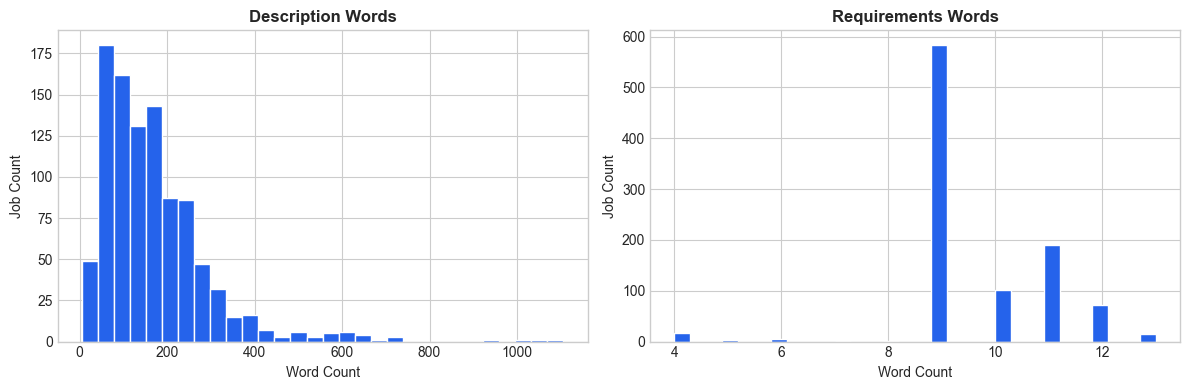

In [4]:
text_length_df = pd.DataFrame({
    'description_words': raw_df['description'].fillna('').astype(str).str.split().str.len(),
    'requirements_words': raw_df['requirements'].fillna('').astype(str).str.split().str.len(),
    'skills_chars': raw_df['Skills'].fillna('').astype(str).str.len(),
})

display(text_length_df.describe().round(2))

axes = text_length_df[['description_words', 'requirements_words']].hist(
    bins=30,
    figsize=(12, 4),
    color='#2563eb',
    edgecolor='white',
)
for ax in axes.flatten():
    ax.set_title(ax.get_title().replace('_', ' ').title())
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Job Count')
plt.tight_layout()
plt.show()

## 4. Preprocessing dan Weak Supervision

Dataset scraping tidak memiliki label kandidat cocok/tidak cocok. Untuk MVP, label dibuat dengan weak supervision:

- Positive pair: kandidat sintetis memenuhi skill, pengalaman, dan pendidikan lowongan.
- Negative pair: kandidat berasal dari role family berbeda atau sengaja dibuat underqualified.

Strategi ini cukup untuk MVP career matching, tetapi versi production sebaiknya dilatih ulang memakai data kandidat nyata dan feedback user.

In [5]:
preprocess_module = importlib.import_module('pipelines.preprocess_jobs')

if RUN_PREPROCESSING or not (PROCESSED_DIR / 'metadata.json').exists():
    preprocess_metadata = preprocess_module.run(
        raw_path=RAW_PATH,
        output_dir=PROCESSED_DIR,
        seed=42,
        negatives_per_job=2,
    )
else:
    preprocess_metadata = json.loads((PROCESSED_DIR / 'metadata.json').read_text(encoding='utf-8'))

preprocess_metadata

{'raw_path': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\data\\raw\\glints_jobs.csv',
 'output_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\data\\processed\\career-match-v1',
 'seed': 42,
 'source_rows': 990,
 'pair_counts': {'train': 2076, 'val': 447, 'test': 447},
 'role_family_distribution': {'it-support-network': 232,
  'qa-security': 161,
  'software-engineering': 140,
  'other-it': 131,
  'data-ai': 115,
  'sales-account': 107,
  'product-project-business': 51,
  'admin-operations': 40,
  'design-content': 13},
 'work_mode_distribution': {'unknown': 866,
  'onsite': 57,
  'remote': 49,
  'hybrid': 18},
 'numeric_features': ['skill_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap'],
 'target': 'binary career match score: 1=relevant candidate profile, 0=not ready/not relevant'}

,split,rows
0,jobs,990
1,train_pairs,2076
2,val_pairs,447
3,test_pairs,447


,count
role_family,
it-support-network,232
qa-security,161
software-engineering,140
other-it,131
data-ai,115
sales-account,107
product-project-business,51
admin-operations,40
design-content,13


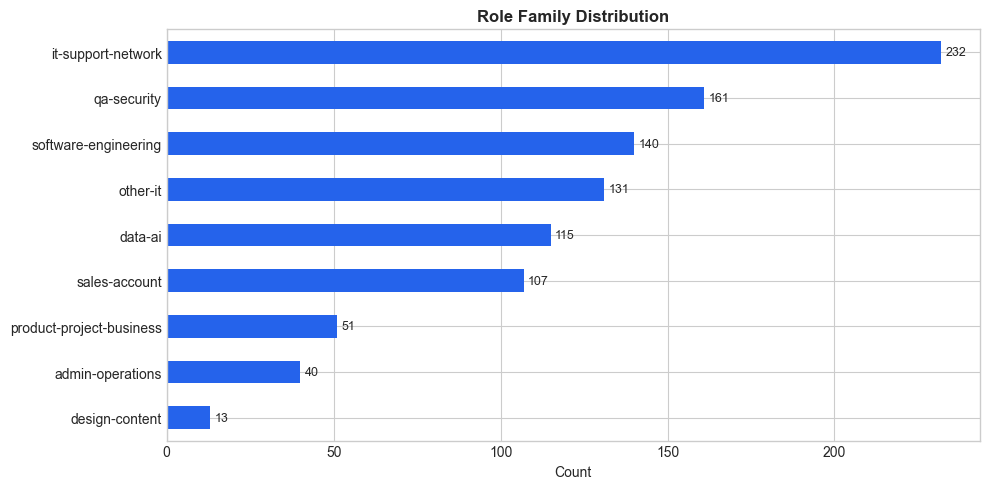

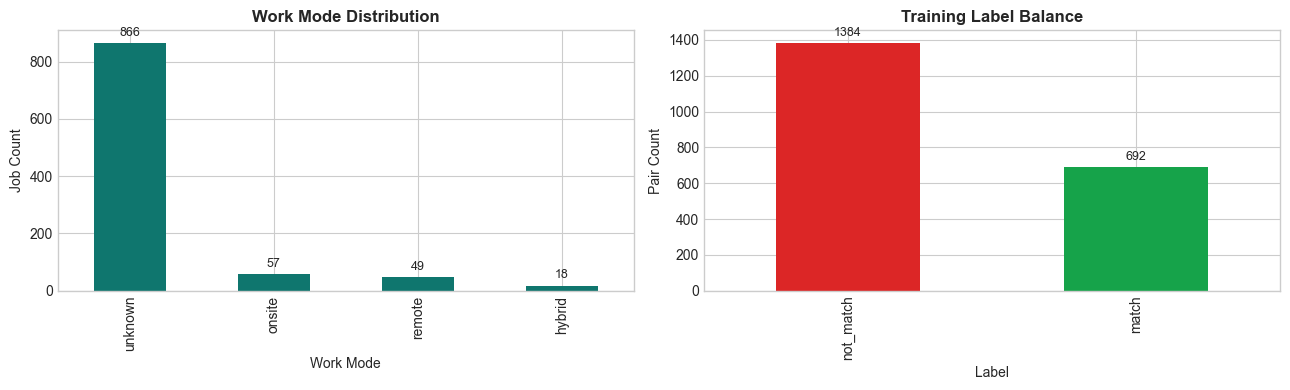

,pair_type,label,count
0,negative_underqualified,0.0,692
1,positive_market_fit,1.0,692
2,negative_cross_role,0.0,692


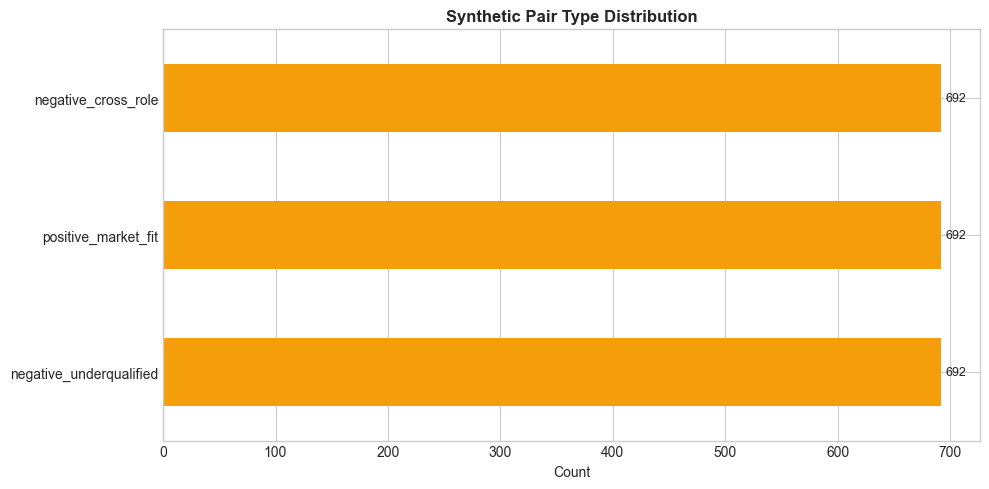

In [6]:
jobs_df = pd.read_csv(PROCESSED_DIR / 'jobs_processed.csv')
train_pairs = pd.read_csv(PROCESSED_DIR / 'train_pairs.csv')
val_pairs = pd.read_csv(PROCESSED_DIR / 'val_pairs.csv')
test_pairs = pd.read_csv(PROCESSED_DIR / 'test_pairs.csv')

processed_summary = pd.DataFrame(
    [
        {'split': 'jobs', 'rows': len(jobs_df)},
        {'split': 'train_pairs', 'rows': len(train_pairs)},
        {'split': 'val_pairs', 'rows': len(val_pairs)},
        {'split': 'test_pairs', 'rows': len(test_pairs)},
    ]
)
display(processed_summary)

role_counts = jobs_df['role_family'].value_counts()
work_mode_counts = jobs_df['work_mode'].value_counts()
pair_type_counts = train_pairs['pair_type'].value_counts()
label_counts = train_pairs['label'].map({0.0: 'not_match', 1.0: 'match'}).value_counts()

display(role_counts.rename('count').to_frame())
plot_barh(role_counts, 'Role Family Distribution', color='#2563eb')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
work_mode_counts.plot(kind='bar', ax=axes[0], color='#0f766e')
axes[0].set_title('Work Mode Distribution')
axes[0].set_xlabel('Work Mode')
axes[0].set_ylabel('Job Count')
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)

label_counts.plot(kind='bar', ax=axes[1], color=['#dc2626', '#16a34a'])
axes[1].set_title('Training Label Balance')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Pair Count')
axes[1].bar_label(axes[1].containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.show()

display(train_pairs[['pair_type', 'label']].value_counts().rename('count').reset_index())
plot_barh(pair_type_counts, 'Synthetic Pair Type Distribution', color='#f59e0b')

,count
it support,187
technical support,138
troubleshooting,135
network troubleshooting,132
communication skills,117
customer service,116
teamwork,107
python,99
hardware maintenance,91
microsoft office,91


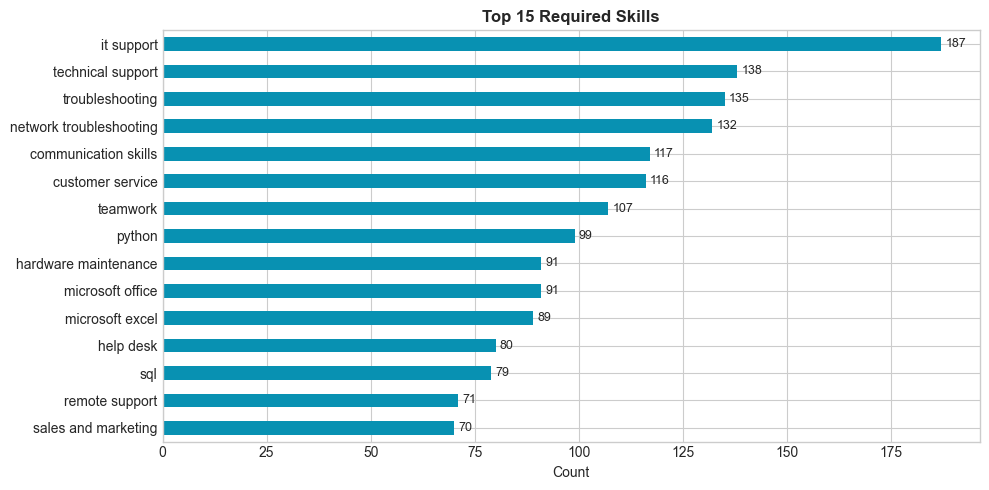

In [7]:
from collections import Counter

skill_counter = Counter()
for value in jobs_df['skills']:
    try:
        skills = json.loads(value) if isinstance(value, str) else value
    except json.JSONDecodeError:
        skills = []
    skill_counter.update(skills)

top_skills = pd.Series(dict(skill_counter.most_common(15)))
display(top_skills.rename('count').to_frame())
plot_barh(top_skills, 'Top 15 Required Skills', color='#0891b2')

## 5. Model Architecture

Model memakai dual text encoder untuk membandingkan `candidate_text` dan `job_text`, lalu digabung dengan fitur numerik readiness. Output akhir adalah sigmoid `match_score` 0 sampai 1.

In [8]:
model_metadata_path = MODEL_DIR / 'metadata.json'
if model_metadata_path.exists():
    model_metadata = json.loads(model_metadata_path.read_text(encoding='utf-8'))
else:
    model_metadata = {
        'status': 'Model belum ditraining. Jalankan cell training dengan RUN_TRAINING=True.'
    }

model_metadata

{'model_name': 'cakapkarier_career_matcher',
 'version': 'v1',
 'framework': 'TensorFlow/Keras',
 'architecture': 'Functional API dual text encoder plus numeric readiness features',
 'custom_components': ['CosineSimilarityLayer',
  'CareerMatchLoss',
  'QualityThresholdCallback',
  'tf.GradientTape custom training loop'],
 'numeric_features': ['skill_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap'],
 'model_path': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\career_match_model.keras',
 'saved_model_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\saved_model',
 'tensorboard_dir': 'C:\\DBS Foundation\\CakapKarier AI\\AIEngine\\models\\registry\\career-match\\v1\\tensorboard',
 'metrics': {'train': {'loss': 0.002785485005006194,
   'binary_accuracy': 0.9995182752609253,
   'mae': 0.008209777064621449},
  'validation': {'loss': 0.005897413939

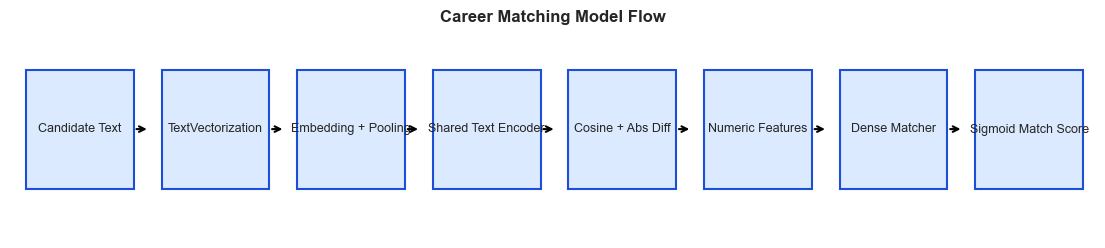

In [9]:
architecture_steps = [
    'Candidate Text',
    'TextVectorization',
    'Embedding + Pooling',
    'Shared Text Encoder',
    'Cosine + Abs Diff',
    'Numeric Features',
    'Dense Matcher',
    'Sigmoid Match Score',
]

fig, ax = plt.subplots(figsize=(14, 2.7))
ax.axis('off')
for idx, label in enumerate(architecture_steps):
    x = idx * 1.7
    box = plt.Rectangle((x, 0.55), 1.35, 0.6, color='#dbeafe', ec='#1d4ed8', lw=1.5)
    ax.add_patch(box)
    ax.text(x + 0.675, 0.85, label, ha='center', va='center', fontsize=9, wrap=True)
    if idx < len(architecture_steps) - 1:
        ax.annotate('', xy=(x + 1.55, 0.85), xytext=(x + 1.35, 0.85), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.set_xlim(-0.2, len(architecture_steps) * 1.7 - 0.2)
ax.set_ylim(0.3, 1.35)
ax.set_title('Career Matching Model Flow')
plt.show()

In [10]:

modeling_module = importlib.import_module('career_match.modeling')
custom_objects = {
    'CosineSimilarityLayer': modeling_module.CosineSimilarityLayer,
    'AbsoluteDifferenceLayer': modeling_module.AbsoluteDifferenceLayer,
}

model = tf.keras.models.load_model(
    MODEL_DIR / 'career_match_model.keras',
    custom_objects=custom_objects,
    compile=False,
)

# Tabel arsitektur seperti contoh model.summary() Keras.
model.summary(line_length=120, expand_nested=True)

model_io = pd.DataFrame(
    [
        {
            'kind': 'input',
            'name': tensor.name,
            'shape': str(tuple(tensor.shape)),
            'dtype': str(tensor.dtype),
        }
        for tensor in model.inputs
    ]
    + [
        {
            'kind': 'output',
            'name': tensor.name,
            'shape': str(tuple(tensor.shape)),
            'dtype': str(tensor.dtype),
        }
        for tensor in model.outputs
    ]
)
display(model_io)

Model: "cakapkarier_career_matcher"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ candidate_text (InputLayer)       │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ job_text (InputLayer)             │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ shared_text_encoder (Functional)  │ (None, 64)                   │           788,864 │ candidate_text[0][0],     
│                                   │                              │                   │ job_text[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text (InputLayer)            │ (None)                       │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ career_text_vectorizer       │ (None, 160)                  │                 0 │ -                         
│ (TextVectorization)               │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ token_embedding (Embedding)  │ (None, 160, 96)              │           768,000 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ masked_average_pooling       │ (None, 96)                   │                 0 │ -                         
│ (GlobalAveragePooling1D)          │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_layer_norm              │ (None, 96)                   │               192 │ -                         
│ (LayerNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_dense_1 (Dense)         │ (None, 128)                  │            12,416 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_dropout (Dropout)       │ (None, 128)                  │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│    └ text_embedding (Dense)       │ (None, 64)                   │             8,256 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_abs_diff                │ (None, 64)                   │                 0 │ shared_text_encoder[0][0],
│ (AbsoluteDifferenceLayer)         │                              │                   │ shared_text_encoder[1][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_product (Multiply)      │ (None, 64)                   │                 0 │ shared_text_encoder[0][0],
│                                   │                              │                   │ shared_text_encoder[1][0] 
├───────────────────────────────────┼───────────────────

 Total params: 844,705 (3.22 MB)

 Trainable params: 844,385 (3.22 MB)

 Non-trainable params: 320 (1.25 KB)

,kind,name,shape,dtype
0,input,candidate_text,"(None,)",string
1,input,job_text,"(None,)",string
2,input,numeric_features,"(None, 6)",float32
3,output,keras_tensor_49,"(None, 1)",float32


## 6. Training, Evaluation, dan Export

Default notebook tidak menjalankan ulang training jika artefak model sudah tersedia. Untuk retraining, ubah `RUN_TRAINING=True` pada cell setup.

In [11]:
from argparse import Namespace

train_module = importlib.import_module('pipelines.train_model')

if RUN_TRAINING or not (MODEL_DIR / 'career_match_model.keras').exists():
    train_args = Namespace(
        processed_dir=PROCESSED_DIR,
        model_dir=MODEL_DIR,
        epochs=20,
        min_epochs=5,
        batch_size=64,
        learning_rate=0.0015,
        max_tokens=8000,
        sequence_length=160,
        embedding_dim=96,
        dropout=0.18,
        seed=42,
        min_accuracy=0.85,
        max_mae=0.02,
        skip_threshold_check=False,
    )
    training_metadata = train_module.run_training(train_args)
else:
    training_metadata = json.loads((MODEL_DIR / 'metadata.json').read_text(encoding='utf-8'))
    print('Training tidak dijalankan ulang. Log epoch final dibaca dari training_history.csv.')
    print('Ubah RUN_TRAINING=True di setup cell jika ingin melihat proses epoch live dari awal.')

training_metadata['metrics']

Training tidak dijalankan ulang. Log epoch final dibaca dari training_history.csv.
Ubah RUN_TRAINING=True di setup cell jika ingin melihat proses epoch live dari awal.


{'train': {'loss': 0.002785485005006194,
  'binary_accuracy': 0.9995182752609253,
  'mae': 0.008209777064621449},
 'validation': {'loss': 0.005897413939237595,
  'binary_accuracy': 0.9932885766029358,
  'mae': 0.015900176018476486},
 'test': {'loss': 0.006696563214063644,
  'binary_accuracy': 0.9955257177352905,
  'mae': 0.015574230812489986},
 'thresholds': {'min_accuracy': 0.85, 'max_mae': 0.02},
 'threshold_callback_reached_epoch': 12}

In [12]:
metrics = json.loads((MODEL_DIR / 'metrics.json').read_text(encoding='utf-8'))
metrics_table = pd.DataFrame(
    [
        {'split': split, **metrics[split]}
        for split in ['train', 'validation', 'test']
    ]
)
display(metrics_table)

test_accuracy = metrics['test']['binary_accuracy']
test_mae = metrics['test']['mae']
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print('Target accuracy >= 0.85:', test_accuracy >= 0.85)
print('Target MAE <= 0.02:', test_mae <= 0.02)

,split,loss,binary_accuracy,mae
0,train,0.002785,0.999518,0.008210
1,validation,0.005897,0.993289,0.015900
2,test,0.006697,0.995526,0.015574


Test accuracy: 0.9955
Test MAE: 0.0156
Target accuracy >= 0.85: True
Target MAE <= 0.02: True


,epoch,loss,binary_accuracy,mae,val_loss,val_binary_accuracy,val_mae,val_accuracy_target_met,val_mae_target_met
0,1,0.03513,0.95809,0.11229,0.09682,0.99776,0.34436,True,False
1,2,0.00525,0.99566,0.03314,0.07410,0.99553,0.30634,True,False
2,3,0.00311,0.99807,0.02948,0.05069,0.99776,0.25824,True,False
3,4,0.00623,0.99711,0.01831,0.03627,0.99105,0.22466,True,False
4,5,0.00659,0.99470,0.02297,0.02534,0.99776,0.16421,True,False
5,6,0.00336,0.99759,0.01956,0.02682,0.99553,0.14971,True,False
6,7,0.00412,0.99663,0.01746,0.01296,0.99776,0.10235,True,False
7,8,0.00852,0.99326,0.01810,0.01703,0.99105,0.09492,True,False
8,9,0.00205,0.99807,0.01594,0.01175,0.99105,0.06892,True,False
9,10,0.00200,0.99807,0.01110,0.00738,0.99329,0.02860,True,False


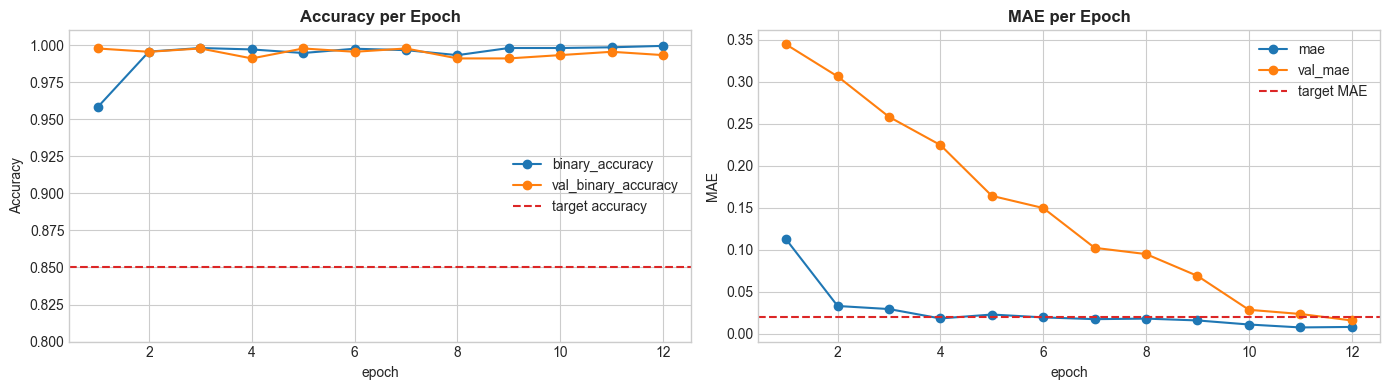

In [13]:
history_path = MODEL_DIR / 'training_history.csv'
history_df = pd.read_csv(history_path)
epoch_log = history_df.copy()
epoch_log['epoch'] = epoch_log['epoch'].astype(int)
epoch_log['val_accuracy_target_met'] = epoch_log['val_binary_accuracy'] >= 0.85
epoch_log['val_mae_target_met'] = epoch_log['val_mae'] <= 0.02
display(epoch_log.round(5))

try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    history_df.plot(x='epoch', y=['binary_accuracy', 'val_binary_accuracy'], marker='o', ax=axes[0])
    axes[0].axhline(0.85, color='#dc2626', linestyle='--', label='target accuracy')
    axes[0].set_title('Accuracy per Epoch')
    axes[0].set_ylim(0.8, 1.01)
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    history_df.plot(x='epoch', y=['mae', 'val_mae'], marker='o', ax=axes[1])
    axes[1].axhline(0.02, color='#dc2626', linestyle='--', label='target MAE')
    axes[1].set_title('MAE per Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Plot dilewati:', exc)

## 7. Exported Artifacts

,artifact,exists,size_mb
0,models\registry\career-match\v1\career_match_m...,True,3.467
1,models\registry\career-match\v1\saved_model,True,6.797
2,models\registry\career-match\v1\jobs_catalog.json,True,2.437
3,models\registry\career-match\v1\metrics.json,True,0.000
4,models\registry\career-match\v1\tensorboard,True,0.031


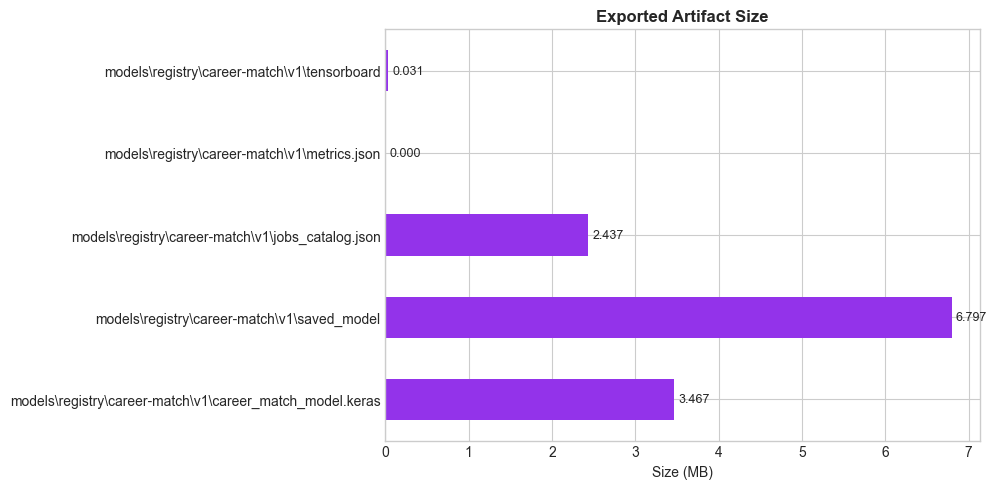

In [14]:
artifact_rows = []
for path in [
    MODEL_DIR / 'career_match_model.keras',
    MODEL_DIR / 'saved_model',
    MODEL_DIR / 'jobs_catalog.json',
    MODEL_DIR / 'metrics.json',
    MODEL_DIR / 'tensorboard',
]:
    if path.is_file():
        size_mb = path.stat().st_size / (1024 * 1024)
    elif path.is_dir():
        size_mb = sum(item.stat().st_size for item in path.rglob('*') if item.is_file()) / (1024 * 1024)
    else:
        size_mb = 0
    artifact_rows.append({'artifact': str(path.relative_to(AIENGINE_ROOT)), 'exists': path.exists(), 'size_mb': round(size_mb, 3)})

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)

ax = artifact_df.set_index('artifact')['size_mb'].plot(kind='barh', color='#9333ea')
ax.set_title('Exported Artifact Size')
ax.set_xlabel('Size (MB)')
ax.set_ylabel('')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## 8. Inference Demo

In [15]:
inference_module = importlib.import_module('career_match.inference')
CareerMatchService = inference_module.CareerMatchService

service = CareerMatchService(MODEL_DIR)
prediction = service.predict(
    skills=['Python', 'SQL', 'Machine Learning', 'Data Analysis', 'TensorFlow'],
    experience_years=2,
    education_level='bachelor',
    certifications=['TensorFlow Developer'],
    preferred_location='Jakarta',
    top_k=5,
)
prediction

{'predicted_role': 'Tenaga Pengajar IT',
 'role_family': 'design-content',
 'readiness_score': 93.3,
 'match_confidence': 0.933,
 'numeric_features': ['skill_overlap',
  'experience_ratio',
  'education_match',
  'skill_count_ratio',
  'missing_skill_ratio',
  'seniority_gap'],
 'top_matches': [{'job_id': '1776679414-790',
   'job_title': 'Tenaga Pengajar IT',
   'company': 'DIGIKIDZ',
   'location': 'Kab. Tangerang, Banten',
   'job_detail': 'https://glints.com/id/en/opportunities/jobs/tenaga-pengajar-it/a308572e-c7e6-4e49-837f-24ee55a60d5c?utm_referrer=explore&traceInfo=17cddaadb4bac2102035b5df6f5fb67e',
   'role_family': 'design-content',
   'work_mode': 'unknown',
   'required_experience_years': 1.0,
   'required_education': 'diploma',
   'match_score': 0.933,
   'readiness_percentage': 93.3,
   'missing_skills': ['pytorch']},
  {'job_id': '1776679699-867',
   'job_title': 'IT Business Analyst Intern',
   'company': 'PT. Borwita Indah',
   'location': 'Jakarta Selatan, DKI Jakarta'

,job_id,job_title,company,location,job_detail,role_family,work_mode,required_experience_years,required_education,match_score,readiness_percentage,missing_skills
0,1776679414-790,Tenaga Pengajar IT,DIGIKIDZ,"Kab. Tangerang, Banten",https://glints.com/id/en/opportunities/jobs/te...,design-content,unknown,1.0,diploma,0.9330,93.30,[pytorch]
1,1776679699-867,IT Business Analyst Intern,PT. Borwita Indah,"Jakarta Selatan, DKI Jakarta",https://glints.com/id/en/opportunities/jobs/it...,qa-security,unknown,0.0,diploma,0.7435,74.35,[it management]
2,1776678050-440,Data Pipeline,Xnine Indonesia,"Jakarta Selatan, DKI Jakarta",https://glints.com/id/en/opportunities/jobs/da...,data-ai,onsite,1.0,bachelor,0.7257,72.57,"[elasticsearch, grafana]"
3,1776678723-610,Data Analyst (ETL Python Tableau) ASAP - WFO J...,PT Sigma Global Teknologi,"Jakarta Selatan, DKI Jakarta",https://glints.com/id/en/opportunities/jobs/da...,data-ai,unknown,3.0,bachelor,0.5607,56.07,"[power bi, tableau]"
4,1776680127-964,IT System & Data Analyst,koperasi kasih indonesia,"Jakarta Utara, DKI Jakarta",https://glints.com/id/en/opportunities/jobs/it...,data-ai,unknown,3.0,diploma,0.5545,55.45,[microsoft excel]


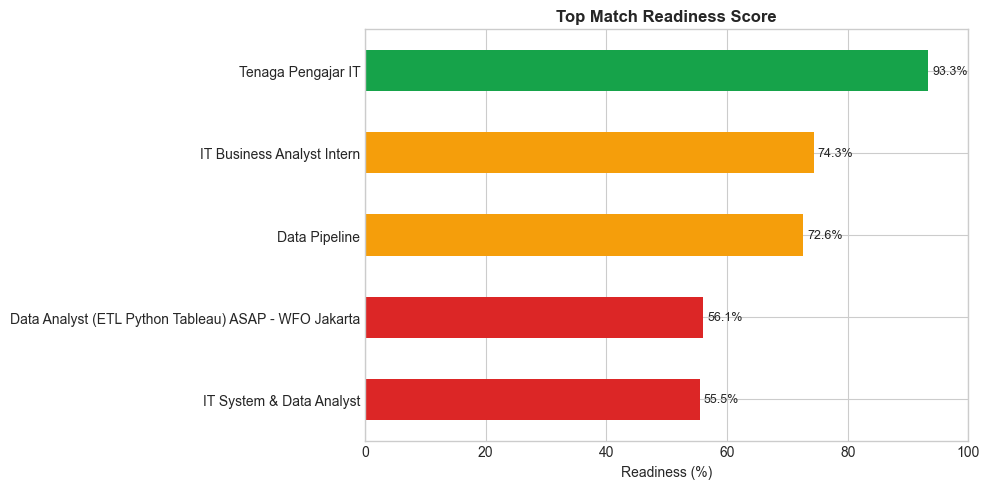

Predicted role: Tenaga Pengajar IT
Readiness score: 93.3
Skill gap: ['pytorch']
Recommendations:
- Bangun bukti portofolio untuk pytorch lewat mini project, latihan studi kasus, dan sertifikasi dasar.


In [16]:
top_matches_df = pd.DataFrame(prediction['top_matches'])
display(top_matches_df)

plot_df = top_matches_df.sort_values('readiness_percentage')
colors = ['#16a34a' if value >= 85 else '#f59e0b' if value >= 70 else '#dc2626' for value in plot_df['readiness_percentage']]
ax = plot_df.plot(kind='barh', x='job_title', y='readiness_percentage', legend=False, color=colors, figsize=(10, 5))
ax.set_title('Top Match Readiness Score')
ax.set_xlabel('Readiness (%)')
ax.set_ylabel('')
ax.set_xlim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print('Predicted role:', prediction['predicted_role'])
print('Readiness score:', prediction['readiness_score'])
print('Skill gap:', prediction['skill_gap'])
print('Recommendations:')
for item in prediction['recommendations']:
    print('-', item)

## 9. REST API Contract

FastAPI service dapat dijalankan dari folder `AIEngine`:

```bash
uvicorn career_match.app:app --app-dir services/career-match/src --host 127.0.0.1 --port 8001
```

Endpoint utama:

- `GET /health`
- `POST /predict`

Kontrak lengkap tersedia di `AIEngine/shared/schemas/career_match_contract.json`.

In [17]:
contract_path = AIENGINE_ROOT / 'shared' / 'schemas' / 'career_match_contract.json'
contract = json.loads(contract_path.read_text(encoding='utf-8'))
contract

{'service': 'career-match',
 'version': '1.0.0',
 'endpoint': 'POST /predict',
 'request': {'skills': {'type': 'array<string>',
   'required': True,
   'description': 'Daftar skill kandidat.'},
  'experience_years': {'type': 'number',
   'required': True,
   'min': 0,
   'max': 60},
  'education_level': {'type': 'string|integer',
   'required': False,
   'examples': ['diploma', 'bachelor', 'master', 3]},
  'certifications': {'type': 'array<string>', 'required': False},
  'preferred_location': {'type': 'string|null', 'required': False},
  'top_k': {'type': 'integer',
   'required': False,
   'default': 5,
   'min': 1,
   'max': 20},
  'use_genai': {'type': 'boolean', 'required': False, 'default': False}},
 'response': {'predicted_role': 'string',
  'role_family': 'string',
  'readiness_score': 'number, 0-100',
  'match_confidence': 'number, 0-1',
  'top_matches': 'array<object>',
  'skill_gap': 'array<string>',
  'recommendations': 'array<string>',
  'ai_summary': 'string|null'},
 'mode

## 10. TensorBoard

TensorBoard event files menyimpan metrik training per epoch. Jika training dijalankan berkali-kali, TensorBoard akan membuat beberapa file event. Itu normal. Untuk final demo, cukup gunakan log terakhir atau kosongkan folder TensorBoard sebelum retraining final.

Jalankan dari folder `AIEngine`:

```bash
tensorboard --logdir models/registry/career-match/v1/tensorboard
```

,run,file,size_kb,last_modified
0,train,events.out.tfevents.1778138474.ASUS-TUF-A15.14...,0.08,1.778138e+09
1,train,events.out.tfevents.1778138502.ASUS-TUF-A15.17...,2.56,1.778139e+09
2,train,events.out.tfevents.1778138611.ASUS-TUF-A15.90...,2.76,1.778139e+09
3,train,events.out.tfevents.1778138739.ASUS-TUF-A15.17...,2.76,1.778139e+09
4,train,events.out.tfevents.1778138892.ASUS-TUF-A15.14...,2.56,1.778139e+09
5,train,events.out.tfevents.1778139036.ASUS-TUF-A15.10...,2.37,1.778139e+09
6,train,events.out.tfevents.1778139147.ASUS-TUF-A15.25...,2.37,1.778139e+09
7,validation,events.out.tfevents.1778138474.ASUS-TUF-A15.14...,0.08,1.778138e+09
8,validation,events.out.tfevents.1778138502.ASUS-TUF-A15.17...,2.72,1.778139e+09
9,validation,events.out.tfevents.1778138611.ASUS-TUF-A15.90...,2.92,1.778139e+09


,file_count,total_size_kb
run,,
train,7,15.46
validation,7,16.38


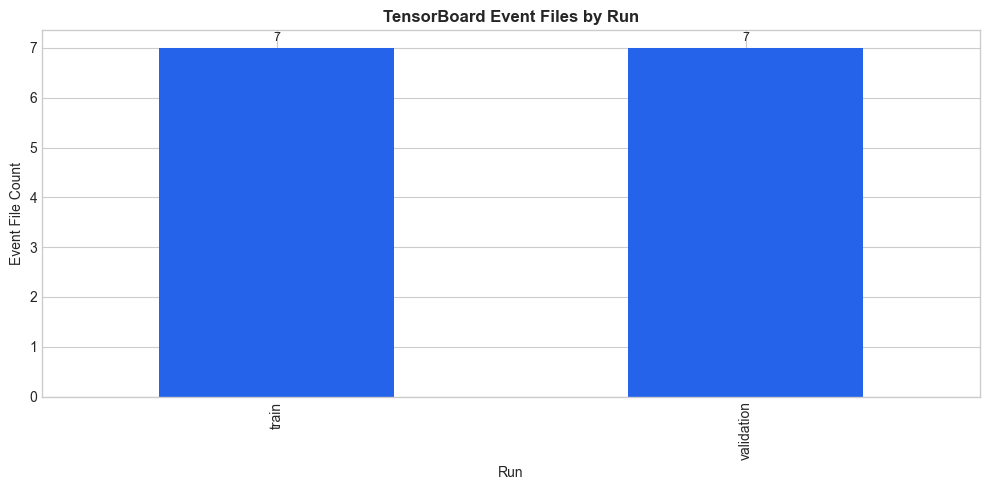

In [18]:
event_files = []
for path in (MODEL_DIR / 'tensorboard').rglob('events.out.tfevents*'):
    event_files.append(
        {
            'run': path.parent.name,
            'file': path.name,
            'size_kb': round(path.stat().st_size / 1024, 2),
            'last_modified': path.stat().st_mtime,
        }
    )

event_df = pd.DataFrame(event_files).sort_values(['run', 'file'])
display(event_df)

if not event_df.empty:
    summary_df = event_df.groupby('run').agg(file_count=('file', 'count'), total_size_kb=('size_kb', 'sum'))
    display(summary_df)
    ax = summary_df['file_count'].plot(kind='bar', color='#2563eb')
    ax.set_title('TensorBoard Event Files by Run')
    ax.set_xlabel('Run')
    ax.set_ylabel('Event File Count')
    ax.bar_label(ax.containers[0], padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()